# Trabalho Computacional 03 — Métodos FEM e FDM em 1D

Neste notebook são resolvidas as duas atividades propostas na Aula 10/11. Primeiro, uma **solução manufaturada** é usada para verificar as implementações do Método de Elementos Finitos (FEM) e do Método de Diferenças Finitas (FDM). Em seguida, os métodos são aplicados ao potencial elétrico em um capacitor com dois dielétricos.

Ao longo do trabalho, $n$ representa o **número total de nós** da malha, incluindo os nós das extremidades. Essa convenção torna natural a exigência de $n$ ímpar na Atividade 02: em uma malha uniforme, o nó central coincide com a interface $z=L/2$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.figsize': (8, 5),
    'axes.grid': True,
    'font.size': 11,
    'lines.linewidth': 2,
})
np.set_printoptions(precision=5, suppress=True)

## Atividade 01 — Teste com uma solução manufaturada

### Definição do problema

Deseja-se resolver

$$\frac{d^2u}{dx^2}=f(x),\qquad x\in(0,1),$$

com condições de Dirichlet $u(0)=u_e(0)$ e $u(1)=u_e(1)$. Para testar os métodos, escolhemos uma função suave que combina um polinômio, uma senoide e uma exponencial:

$$u_e(x)=x^3+\sin(2\pi x)+e^x.$$

A fonte é fabricada derivando essa expressão duas vezes:

$$f(x)=u_e''(x)=6x-4\pi^2\sin(2\pi x)+e^x.$$

Assim, a solução exata do problema é conhecida antes da solução numérica, o que permite medir diretamente o erro de cada método.

In [2]:
def u_exata(x):
    x = np.asarray(x)
    return x**3 + np.sin(2*np.pi*x) + np.exp(x)

def fonte(x):
    x = np.asarray(x)
    return 6*x - 4*np.pi**2*np.sin(2*np.pi*x) + np.exp(x)

u0, u1 = float(u_exata(0.0)), float(u_exata(1.0))
print(f'Condições de contorno: u(0) = {u0:.6f}, u(1) = {u1:.6f}')

Condições de contorno: u(0) = 1.000000, u(1) = 3.718282


### Forma fraca e discretização pelo FEM

Multiplicando a equação por uma função de peso $w$, nula nas duas extremidades, e integrando no domínio:

$$\int_0^1 w\,u_{,xx}\,dx=\int_0^1 wf\,dx.$$

A integração por partes fornece

$$\left.wu_{,x}\right|_0^1-\int_0^1 w_{,x}u_{,x}\,dx=\int_0^1 wf\,dx.$$

Como $w(0)=w(1)=0$, o termo de contorno desaparece. A forma fraca é, portanto,

$$\boxed{\int_0^1 w_{,x}u_{,x}\,dx=-\int_0^1 wf\,dx.}$$

Usando Galerkin e funções de forma lineares em cada elemento $e=[x_i,x_{i+1}]$, obtém-se

$$\mathbf K^{(e)}=\frac{1}{h_e}\begin{bmatrix}1&-1\\-1&1\end{bmatrix},\qquad\mathbf F^{(e)}=-\int_{x_i}^{x_{i+1}}\mathbf N^T f\,dx.$$

A integral do vetor de carga será calculada por quadratura de Gauss com três pontos. As condições de Dirichlet serão impostas por eliminação, mantendo apenas as incógnitas internas.

In [3]:
def resolver_fem_poisson(n, f=fonte, ua=u0, ub=u1):
    """Resolve u''=f em [0,1] com elementos lineares e n nós."""
    x = np.linspace(0.0, 1.0, n)
    K = np.zeros((n, n))
    F = np.zeros(n)
    pontos_g, pesos_g = np.polynomial.legendre.leggauss(3)

    for e in range(n - 1):
        xa, xb = x[e], x[e + 1]
        h = xb - xa
        Ke = np.array([[1.0, -1.0], [-1.0, 1.0]]) / h
        Fe = np.zeros(2)
        for xi_g, peso in zip(pontos_g, pesos_g):
            N = np.array([(1.0 - xi_g)/2.0, (1.0 + xi_g)/2.0])
            x_g = N @ np.array([xa, xb])
            Fe += -N * f(x_g) * peso * h/2.0
        ids = np.array([e, e + 1])
        K[np.ix_(ids, ids)] += Ke
        F[ids] += Fe

    u = np.zeros(n)
    u[[0, -1]] = [ua, ub]
    internos = np.arange(1, n - 1)
    contorno = np.array([0, n - 1])
    u[internos] = np.linalg.solve(
        K[np.ix_(internos, internos)],
        F[internos] - K[np.ix_(internos, contorno)] @ u[contorno]
    )
    return x, u

# Pequeno teste de consistência: a matriz montada deve ser simétrica.
x_fem_teste, u_fem_teste = resolver_fem_poisson(6)
print('Solução FEM calculada em 6 nós:', u_fem_teste)

Solução FEM calculada em 6 nós: [1.      2.18045 2.1436  1.45034 1.78649 3.71828]


### Discretização pelo FDM

Em uma malha uniforme de espaçamento $h$, a derivada segunda em um nó interno é aproximada pela diferença central

$$u''(x_i)\approx\frac{u_{i-1}-2u_i+u_{i+1}}{h^2}.$$

Consequentemente, para cada nó interno,

$$u_{i-1}-2u_i+u_{i+1}=h^2f(x_i).$$

As contribuições dos valores conhecidos nas extremidades são transferidas para o lado direito do sistema.

In [4]:
def resolver_fdm_poisson(n, f=fonte, ua=u0, ub=u1):
    """Resolve u''=f em [0,1] por diferenças centrais e n nós."""
    x = np.linspace(0.0, 1.0, n)
    h = x[1] - x[0]
    m = n - 2
    A = np.diag(-2.0*np.ones(m))
    if m > 1:
        A += np.diag(np.ones(m - 1), 1) + np.diag(np.ones(m - 1), -1)
    b = h**2 * f(x[1:-1])
    b[0] -= ua
    b[-1] -= ub
    u = np.empty(n)
    u[[0, -1]] = [ua, ub]
    u[1:-1] = np.linalg.solve(A, b)
    return x, u

### Comparação das soluções para $n=6$

As soluções discretas são ligadas por segmentos de reta somente para facilitar a visualização. A curva preta representa a solução analítica.

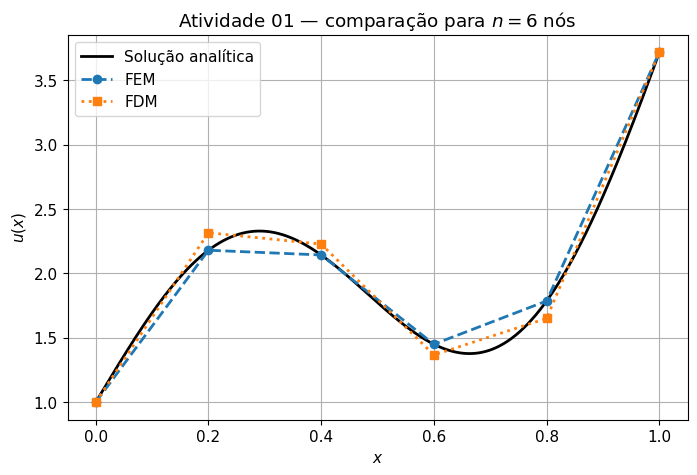

Erro máximo nos nós:
  FEM: 1.002775e-05
  FDM: 1.360978e-01


In [5]:
n_comparacao = 6
x_fem, u_fem = resolver_fem_poisson(n_comparacao)
x_fdm, u_fdm = resolver_fdm_poisson(n_comparacao)
x_plot = np.linspace(0.0, 1.0, 1001)

fig, ax = plt.subplots()
ax.plot(x_plot, u_exata(x_plot), 'k-', label='Solução analítica')
ax.plot(x_fem, u_fem, 'o--', label='FEM')
ax.plot(x_fdm, u_fdm, 's:', label='FDM')
ax.set(xlabel='$x$', ylabel='$u(x)$', title='Atividade 01 — comparação para $n=6$ nós')
ax.legend()
plt.show()

print('Erro máximo nos nós:')
print(f'  FEM: {np.max(np.abs(u_fem-u_exata(x_fem))):.6e}')
print(f'  FDM: {np.max(np.abs(u_fdm-u_exata(x_fdm))):.6e}')

### Estudo de convergência

Para comparar métodos definidos em nós com a solução contínua, ambos os resultados numéricos são interpolados linearmente em uma malha fina comum. O erro médio quadrático (MSE) é calculado por

$$\mathrm{MSE}=\frac{1}{N_s}\sum_{j=1}^{N_s}\left[u_h(x_j)-u_e(x_j)\right]^2.$$

Também é apresentada a raiz desse erro (RMSE), que possui a mesma unidade de $u$. A ordem observada $p$ é estimada por uma regressão linear de $\log(\mathrm{RMSE})$ em função de $\log(h)$.

 n       MSE FEM       MSE FDM      RMSE FEM      RMSE FDM
 4   7.96693e-02   4.17925e-02   2.82257e-01   2.04432e-01
 8   3.04465e-03   7.10401e-04   5.51783e-02   2.66533e-02
16   1.47683e-04   2.97197e-05   1.21525e-02   5.45158e-03
32   8.13467e-06   1.58571e-06   2.85214e-03   1.25925e-03

Ordem observada usando RMSE: FEM = 1.969; FDM = 2.173


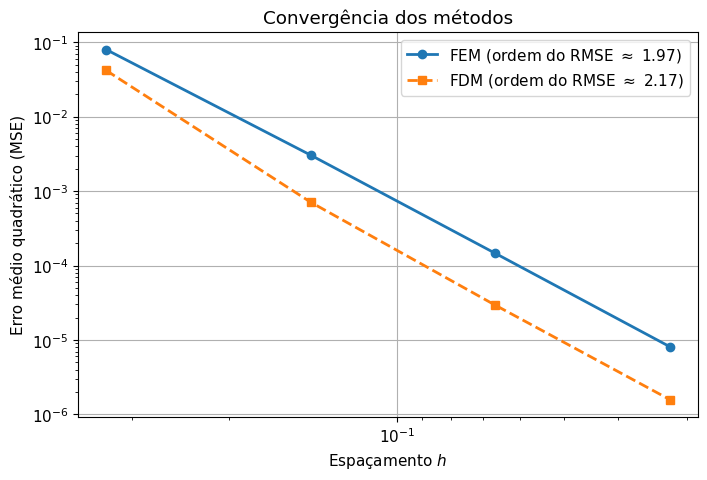

In [6]:
def mse_continuo(x_nos, u_nos, x_amostra):
    u_interp = np.interp(x_amostra, x_nos, u_nos)
    return np.mean((u_interp - u_exata(x_amostra))**2)

valores_n = np.array([4, 8, 16, 32])
x_amostra = np.linspace(0.0, 1.0, 10001)
mse_fem, mse_fdm = [], []

for n in valores_n:
    xfem, ufem = resolver_fem_poisson(n)
    xfdm, ufdm = resolver_fdm_poisson(n)
    mse_fem.append(mse_continuo(xfem, ufem, x_amostra))
    mse_fdm.append(mse_continuo(xfdm, ufdm, x_amostra))

mse_fem, mse_fdm = np.array(mse_fem), np.array(mse_fdm)
rmse_fem, rmse_fdm = np.sqrt(mse_fem), np.sqrt(mse_fdm)
h = 1.0/(valores_n - 1)
p_fem = np.polyfit(np.log(h), np.log(rmse_fem), 1)[0]
p_fdm = np.polyfit(np.log(h), np.log(rmse_fdm), 1)[0]

print(' n       MSE FEM       MSE FDM      RMSE FEM      RMSE FDM')
for n, ef, ed, rf, rd in zip(valores_n, mse_fem, mse_fdm, rmse_fem, rmse_fdm):
    print(f'{n:2d}  {ef:12.5e}  {ed:12.5e}  {rf:12.5e}  {rd:12.5e}')
print(f'\nOrdem observada usando RMSE: FEM = {p_fem:.3f}; FDM = {p_fdm:.3f}')

fig, ax = plt.subplots()
ax.loglog(h, mse_fem, 'o-', label=f'FEM (ordem do RMSE $\\approx$ {p_fem:.2f})')
ax.loglog(h, mse_fdm, 's--', label=f'FDM (ordem do RMSE $\\approx$ {p_fdm:.2f})')
ax.invert_xaxis()
ax.set(xlabel='Espaçamento $h$', ylabel='Erro médio quadrático (MSE)',
       title='Convergência dos métodos')
ax.legend()
plt.show()

Como foram usadas aproximações lineares, espera-se que o RMSE decaia aproximadamente com $h^2$ em uma solução suficientemente suave. Consequentemente, o MSE, que é o quadrado do RMSE, apresenta inclinação próxima de quatro em escala logarítmica. Os valores calculados acima permitem confirmar numericamente esse comportamento.

## Atividade 02 — Capacitor com dois dielétricos

### Forma forte e dados

O potencial elétrico $\phi(z)$ satisfaz

$$\frac{d}{dz}\left(\varepsilon_r(z)\frac{d\phi}{dz}\right)=0,\qquad z\in(0,L),$$

$$\phi(0)=V_a,\qquad \phi(L)=V_b,$$

com

$$L=1,\quad V_a=10,\quad V_b=0,\quad\varepsilon_r(z)=\begin{cases}3,&z<L/2,\\1,&z\ge L/2.\end{cases}$$

> **Observação:** o slide 48 escreve $V_a$ duas vezes. Adota-se $V_b=0$, conforme a segunda condição de contorno definida no slide anterior e a ilustração do capacitor.

### Forma fraca

Como $\varepsilon_r$ é constante em cada material, separamos inicialmente a integral nas regiões $\Omega_1=(0,L/2)$ e $\Omega_2=(L/2,L)$. Multiplicando por uma função de peso $w$, com $w(0)=w(L)=0$, temos

$$\int_0^{L/2}w(\varepsilon_1\phi_{,z})_{,z}\,dz+\int_{L/2}^{L}w(\varepsilon_2\phi_{,z})_{,z}\,dz=0.$$

Integrando cada parcela por partes:

$$-\int_0^{L/2}w_{,z}\varepsilon_1\phi_{,z}\,dz-\int_{L/2}^{L}w_{,z}\varepsilon_2\phi_{,z}\,dz+w(L/2)\left[\varepsilon_1\phi_{,z}(L/2^-)-\varepsilon_2\phi_{,z}(L/2^+)\right]=0.$$

A ausência de carga livre na interface impõe a continuidade do fluxo normal,

$$\varepsilon_1\phi_{,z}(L/2^-)=\varepsilon_2\phi_{,z}(L/2^+),$$

de modo que o termo de interface se cancela. A forma fraca final é

$$\boxed{\int_0^L \varepsilon_r(z)w_{,z}\phi_{,z}\,dz=0.}$$

No FEM, cada elemento permanece inteiramente dentro de um material porque há um nó em $L/2$. Sua matriz local é

$$\mathbf K^{(e)}=\frac{\varepsilon_r^{(e)}}{h_e}\begin{bmatrix}1&-1\\-1&1\end{bmatrix}.$$

In [7]:
L, Va, Vb = 1.0, 10.0, 0.0

def epsilon_r(z):
    z = np.asarray(z)
    return np.where(z < L/2.0, 3.0, 1.0)

def phi_exata(z):
    """Solução obtida pela constância de eps*dphi/dz."""
    z = np.asarray(z)
    resistencia_total = (L/2.0)/3.0 + (L/2.0)/1.0
    fluxo = (Vb - Va)/resistencia_total
    integral_inv_eps = np.where(z <= L/2.0, z/3.0, (L/2.0)/3.0 + (z-L/2.0))
    return Va + fluxo*integral_inv_eps

def resolver_fem_capacitor(n):
    if n % 2 == 0:
        raise ValueError('n deve ser ímpar para haver um nó em z=L/2.')
    z = np.linspace(0.0, L, n)
    K = np.zeros((n, n))
    for e in range(n - 1):
        h = z[e+1] - z[e]
        eps_e = float(epsilon_r((z[e] + z[e+1])/2.0))
        Ke = eps_e/h * np.array([[1.0, -1.0], [-1.0, 1.0]])
        ids = np.array([e, e+1])
        K[np.ix_(ids, ids)] += Ke
    phi = np.zeros(n)
    phi[[0, -1]] = [Va, Vb]
    internos = np.arange(1, n-1)
    contorno = np.array([0, n-1])
    phi[internos] = np.linalg.solve(
        K[np.ix_(internos, internos)],
        -K[np.ix_(internos, contorno)] @ phi[contorno]
    )
    return z, phi

### FDM conservativo para coeficiente descontínuo

Aplicar diretamente uma diferença central à forma expandida seria inadequado na interface, onde $\varepsilon_r$ é descontínua. Em vez disso, discretizamos a conservação do fluxo em cada volume nodal:

$$\frac{1}{h}\left[\varepsilon_{i+1/2}\frac{\phi_{i+1}-\phi_i}{h}-\varepsilon_{i-1/2}\frac{\phi_i-\phi_{i-1}}{h}\right]=0.$$

O coeficiente $\varepsilon_{i+1/2}$ é avaliado no ponto médio entre os nós. Como a interface coincide com um nó, cada ponto médio pertence inequivocamente a um dos dielétricos. Essa formulação conserva o fluxo elétrico através da interface.

In [8]:
def resolver_fdm_capacitor(n):
    if n % 2 == 0:
        raise ValueError('n deve ser ímpar para haver um nó em z=L/2.')
    z = np.linspace(0.0, L, n)
    h = z[1] - z[0]
    eps_faces = epsilon_r((z[:-1] + z[1:])/2.0)
    m = n - 2
    A = np.zeros((m, m))
    b = np.zeros(m)
    for j, i in enumerate(range(1, n-1)):
        eps_oeste, eps_leste = eps_faces[i-1], eps_faces[i]
        A[j, j] = -(eps_oeste + eps_leste)/h**2
        if j > 0:
            A[j, j-1] = eps_oeste/h**2
        else:
            b[j] -= eps_oeste*Va/h**2
        if j < m-1:
            A[j, j+1] = eps_leste/h**2
        else:
            b[j] -= eps_leste*Vb/h**2
    phi = np.empty(n)
    phi[[0, -1]] = [Va, Vb]
    phi[1:-1] = np.linalg.solve(A, b)
    return z, phi

### Resultados e comparação

É escolhida uma malha uniforme com $n=21$ nós. O nó de índice central está em $z=0{,}5$, exatamente na interface. A solução analítica é linear por partes: o potencial é contínuo, enquanto sua inclinação muda para manter $\varepsilon_r\phi_{,z}$ contínuo.

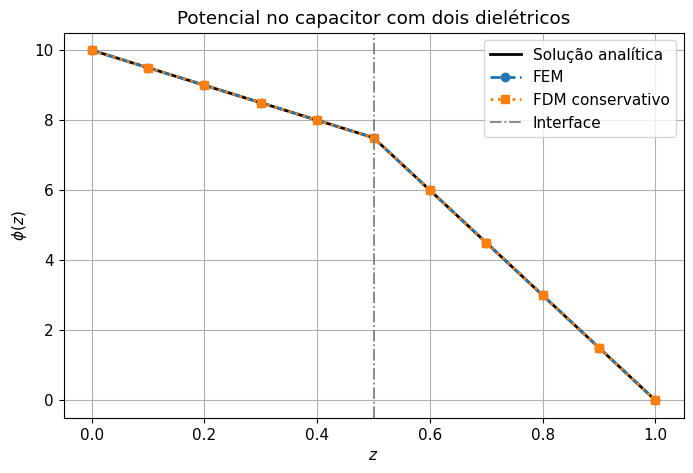

Nó da interface: z = 0.500
Potencial na interface: phi = 7.500000 V
Erro máximo FEM: 1.421085e-14 V
Erro máximo FDM: 7.105427e-15 V


In [9]:
n_capacitor = 21
z_fem, phi_fem = resolver_fem_capacitor(n_capacitor)
z_fdm, phi_fdm = resolver_fdm_capacitor(n_capacitor)
z_plot = np.linspace(0.0, L, 1001)

fig, ax = plt.subplots()
ax.plot(z_plot, phi_exata(z_plot), 'k-', label='Solução analítica')
ax.plot(z_fem, phi_fem, 'o--', markevery=2, label='FEM')
ax.plot(z_fdm, phi_fdm, 's:', markevery=2, label='FDM conservativo')
ax.axvline(L/2, color='0.5', linestyle='-.', linewidth=1.3, label='Interface')
ax.set(xlabel='$z$', ylabel='$\\phi(z)$', title='Potencial no capacitor com dois dielétricos')
ax.legend()
plt.show()

erro_fem = np.max(np.abs(phi_fem - phi_exata(z_fem)))
erro_fdm = np.max(np.abs(phi_fdm - phi_exata(z_fdm)))
i_interface = np.argmin(np.abs(z_fem-L/2))
print(f'Nó da interface: z = {z_fem[i_interface]:.3f}')
print(f'Potencial na interface: phi = {phi_fem[i_interface]:.6f} V')
print(f'Erro máximo FEM: {erro_fem:.6e} V')
print(f'Erro máximo FDM: {erro_fdm:.6e} V')

### Verificação da continuidade do fluxo

Para finalizar, calculamos o fluxo discreto $q_e=\varepsilon_r\,\Delta\phi/\Delta z$ em cada intervalo. Ele deve permanecer constante, inclusive ao atravessar a interface.

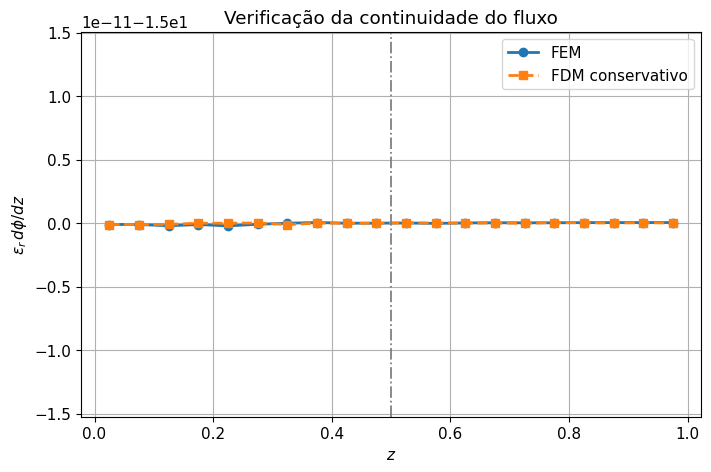

Variação do fluxo no FEM: 2.664535e-13
Variação do fluxo no FDM: 1.492140e-13


In [10]:
z_meio = (z_fem[:-1] + z_fem[1:])/2.0
fluxo_fem = epsilon_r(z_meio)*np.diff(phi_fem)/np.diff(z_fem)
fluxo_fdm = epsilon_r(z_meio)*np.diff(phi_fdm)/np.diff(z_fdm)

fig, ax = plt.subplots()
ax.plot(z_meio, fluxo_fem, 'o-', label='FEM')
ax.plot(z_meio, fluxo_fdm, 's--', label='FDM conservativo')
ax.axvline(L/2, color='0.5', linestyle='-.', linewidth=1.3)
ax.set(xlabel='$z$', ylabel='$\\varepsilon_r\\,d\\phi/dz$',
       title='Verificação da continuidade do fluxo')
ax.legend()
plt.show()

print(f'Variação do fluxo no FEM: {np.ptp(fluxo_fem):.6e}')
print(f'Variação do fluxo no FDM: {np.ptp(fluxo_fdm):.6e}')

## Conclusões

A solução manufaturada permitiu verificar quantitativamente as duas implementações. Tanto o FEM linear quanto o FDM com diferenças centrais apresentam redução sistemática do erro com o refinamento da malha.

No capacitor, a colocação de um nó na interface evita que um elemento atravesse dois materiais. O FEM incorpora diretamente $\varepsilon_r$ na matriz de rigidez, enquanto o FDM foi escrito em forma conservativa. As duas formulações preservam a continuidade do fluxo e reproduzem a solução linear por partes.